In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load Dataset
df = pd.read_csv("Amazon_Sale_Report.csv")
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [5]:
df.shape

(128976, 21)

In [ ]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  str    
 2   Date                128976 non-null  str    
 3   Status              128976 non-null  str    
 4   Fulfilment          128976 non-null  str    
 5   Sales Channel       128976 non-null  str    
 6   ship-service-level  128976 non-null  str    
 7   Category            128976 non-null  str    
 8   Size                128976 non-null  str    
 9   Courier Status      128976 non-null  str    
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  str    
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  str    
 14  ship-state          128941 non-null  str    
 15  ship-postal-code    128941 non-null  float64


In [5]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [ ]:
df.isna().sum()


index                      0
Order ID                   0
Date                       0
Status                     0
Fulfilment                 0
Sales Channel              0
ship-service-level         0
Category                   0
Size                       0
Courier Status             0
Qty                        0
currency                7800
Amount                  7800
ship-city                 35
ship-state                35
ship-postal-code          35
ship-country              35
B2B                        0
fulfilled-by           89713
New                   128976
PendingS              128976
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(168)

Cleaning of Dataset

In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df["Date"]

0        2022-04-30
1        2022-04-30
2        2022-04-30
3        2022-04-30
4        2022-04-30
            ...    
128971   2022-05-31
128972   2022-05-31
128973   2022-05-31
128974   2022-05-31
128975   2022-05-31
Name: Date, Length: 128976, dtype: datetime64[us]

In [ ]:
df.drop(columns= ["New", "PendingS"], inplace=True)


In [ ]:
df

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128971,128970,406-6001380-7673107,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,False,NaN
128972,128971,402-9551604-7544318,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,1,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,False,NaN
128973,128972,407-9547469-3152358,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,Blazzer,XXL,Shipped,1,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,False,NaN
128974,128973,402-6184140-0545956,2022-05-31,Shipped,Amazon,Amazon.in,Expedited,T-shirt,XS,Shipped,1,INR,1199.00,Halol,Gujarat,389350.0,IN,False,NaN


In [ ]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Category                  0
Size                      0
Courier Status            0
Qty                       0
currency               7789
Amount                 7789
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
B2B                       0
fulfilled-by          89595
dtype: int64

In [ ]:
df.shape

(128808, 19)

In [ ]:
df["ship-city"] = df["ship-city"].fillna("Unknown")
df["ship-state"] = df["ship-state"].fillna("Unknown")
df["ship-country"] = df["ship-country"].fillna("Unknown")
df["ship-postal-code"] = df["ship-postal-code"].fillna(df["ship-postal-code"].median())

In [ ]:
df = df.dropna(subset=["Amount"])

In [ ]:
df.isnull().sum()

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Category                  0
Size                      0
Courier Status            0
Qty                       0
currency                  0
Amount                    0
ship-city                 0
ship-state                0
ship-postal-code          0
ship-country              0
B2B                       0
fulfilled-by          83542
dtype: int64

data is cleaned almost 

Exploratory Data Analysis

# Explore the data 
1. Univariate Analysis

In [ ]:
# Dataset Overveiw
df.shape

(121019, 19)

In [8]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='str')

In [ ]:
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  str    
 2   Date                128976 non-null  str    
 3   Status              128976 non-null  str    
 4   Fulfilment          128976 non-null  str    
 5   Sales Channel       128976 non-null  str    
 6   ship-service-level  128976 non-null  str    
 7   Category            128976 non-null  str    
 8   Size                128976 non-null  str    
 9   Courier Status      128976 non-null  str    
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  str    
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  str    
 14  ship-state          128941 non-null  str    
 15  ship-postal-code    128941 non-null  float64


In [ ]:
# Category Distribution
df["Category"].value_counts()

Category
T-shirt     46980
Shirt       46645
Blazzer     14694
Trousers    10151
Perfume      1091
Wallet        881
Socks         419
Shoes         155
Watch           3
Name: count, dtype: int64

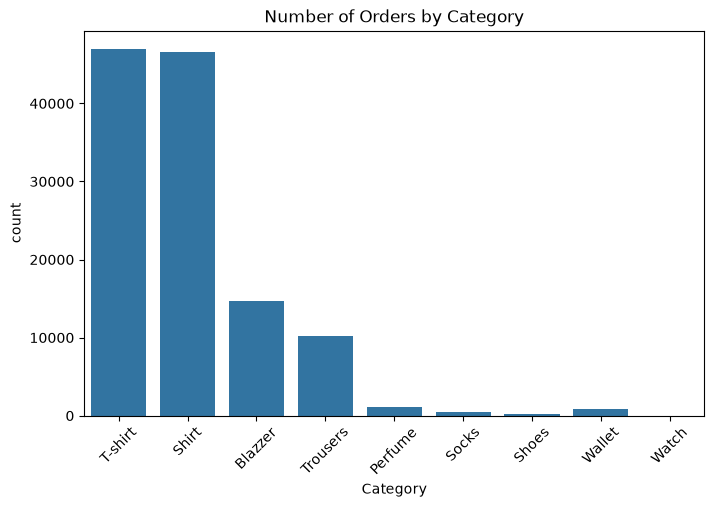

In [ ]:
# Visulaization
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Category")
plt.xticks(rotation=45)
plt.title("Number of Orders by Category")
plt.show()

In [ ]:
# Order Status
df["Status"].value_counts()

Status
Shipped                          77505
Shipped - Delivered to Buyer     28707
Cancelled                        10751
Shipped - Returned to Seller      1949
Shipped - Picked Up                973
Pending                            656
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

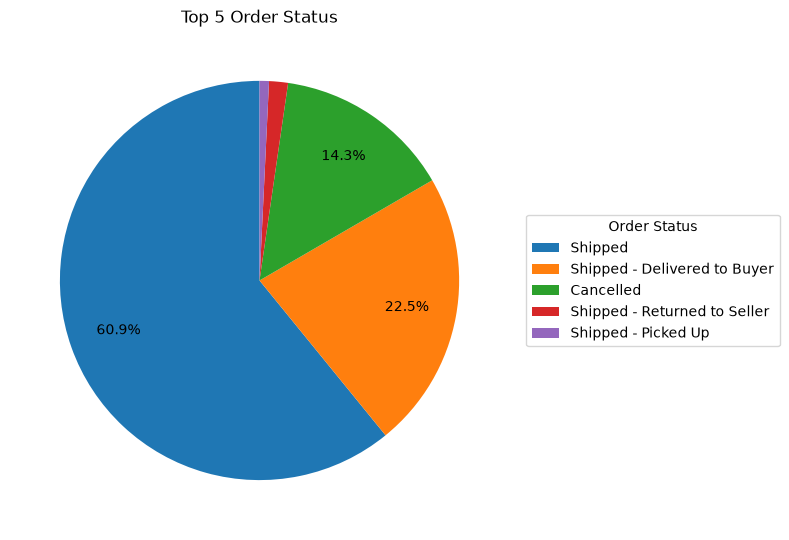

In [13]:
status = df["Status"].value_counts().head(5)

plt.figure(figsize=(8,8))

plt.pie(
    status,
    startangle=90,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    pctdistance=0.75
)

plt.legend(
    status.index,
    title="Order Status",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.title("Top 5 Order Status")
plt.tight_layout()
plt.show()

In [ ]:
# Size Distribution
df["Size"].value_counts()


Size
M       20948
L       20461
XL      19394
XXL     16767
S       15630
3XL     13870
XS      10180
Free     2130
6XL       705
5XL       526
4XL       408
Name: count, dtype: int64

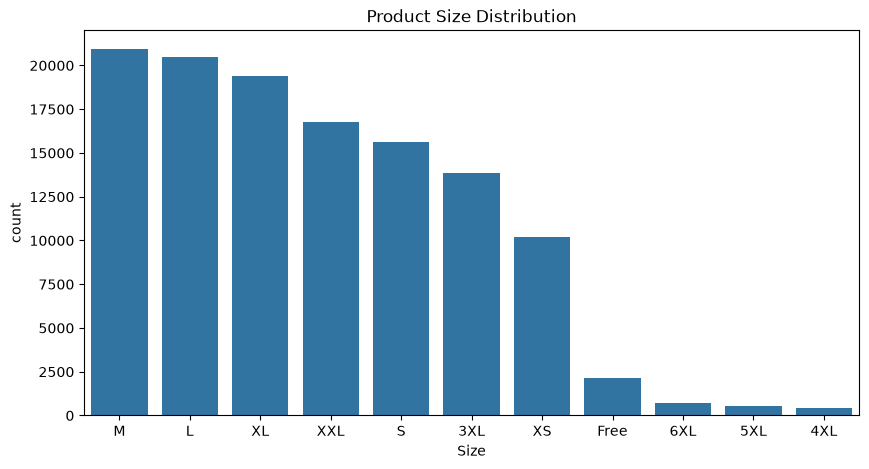

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="Size", order = df["Size"].value_counts().index)
plt.title("Product Size Distribution")
plt.show()

In [ ]:
# Fulfilment
df["Fulfilment"].value_counts()

Fulfilment
Amazon      83542
Merchant    37477
Name: count, dtype: int64

2. Numerical Analysis

In [14]:
# Quantity
df["Qty"].describe()

count    128976.000000
mean          0.904401
std           0.313368
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          15.000000
Name: Qty, dtype: float64

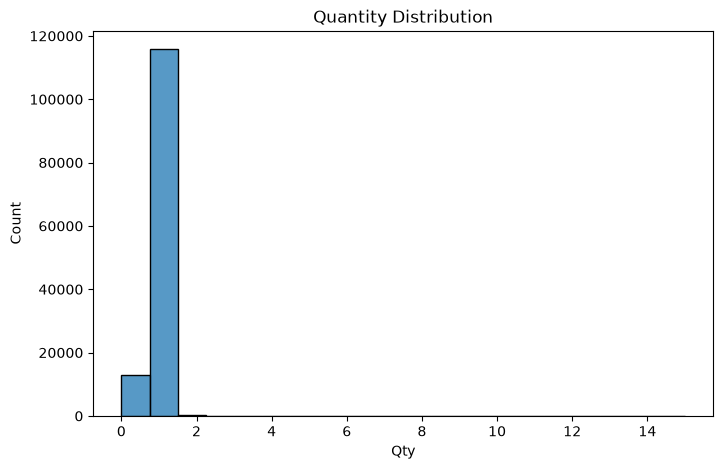

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Qty"], bins=20)
plt.title("Quantity Distribution")
plt.show()

In [16]:
# Amount
df["Amount"].describe()

count    121176.000000
mean        648.562176
std         281.185041
min           0.000000
25%         449.000000
50%         605.000000
75%         788.000000
max        5584.000000
Name: Amount, dtype: float64

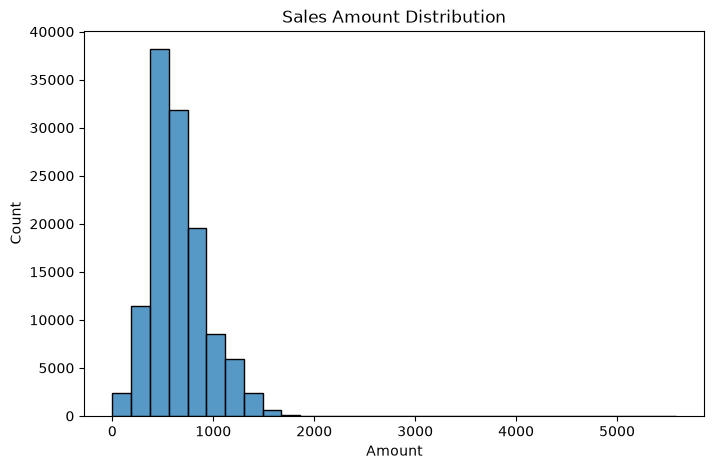

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["Amount"], bins=30)
plt.title("Sales Amount Distribution")
plt.show()

3. Bivariate Analysis

In [18]:
# Sales by category
sales_category = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
sales_category

Category
T-shirt     39206756.65
Shirt       21297770.08
Blazzer     11215104.12
Trousers     5346286.30
Perfume       789419.66
Wallet        458408.18
Socks         150757.50
Shoes         124752.76
Watch            915.00
Name: Amount, dtype: float64

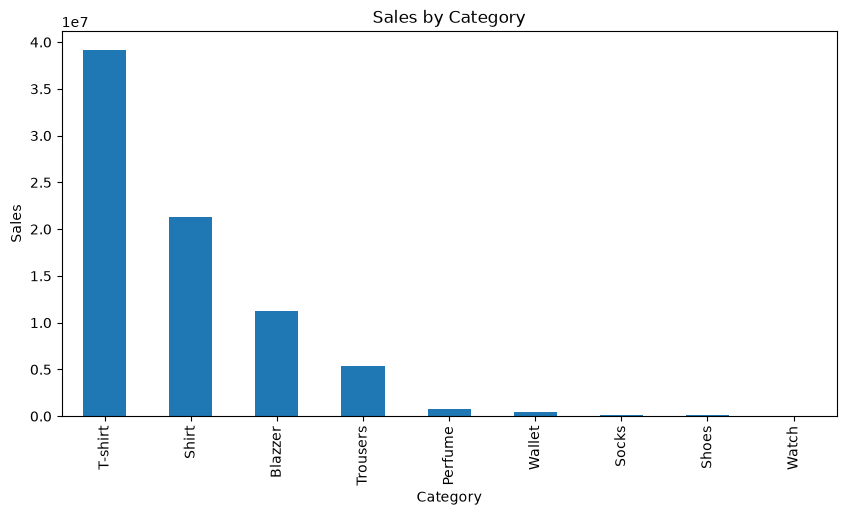

In [19]:
sales_category.plot(kind="bar", figsize=(10,5))
plt.ylabel("Sales")
plt.title("Sales by Category")
plt.show()

In [20]:
# Sales br state
top_state = df.groupby("ship-state")["Amount"].sum().sort_values(ascending=False).head(10)

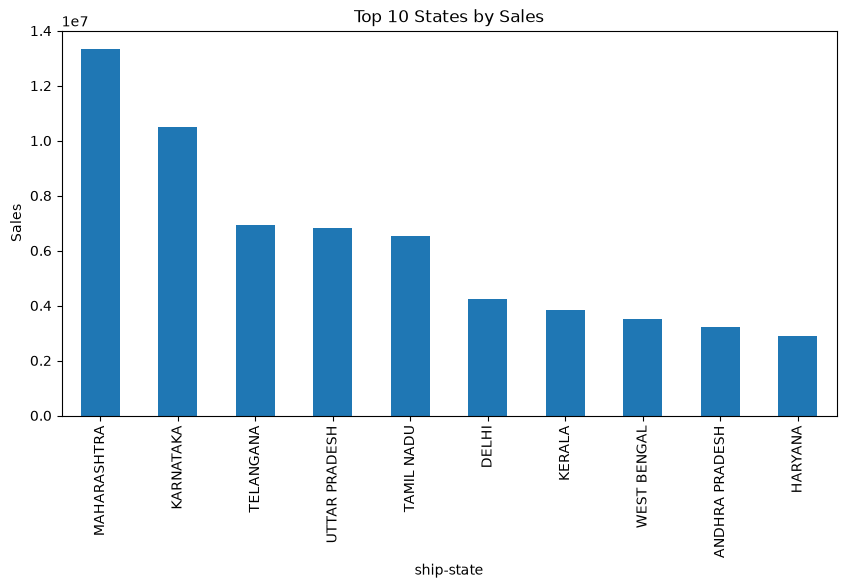

In [21]:
top_state.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Sales")
plt.ylabel("Sales")
plt.show()

In [23]:
# order by city
df["ship-city"].value_counts().head(10)

ship-city
BENGALURU    11208
HYDERABAD     8077
MUMBAI        6125
NEW DELHI     5792
CHENNAI       5430
PUNE          3863
KOLKATA       2380
GURUGRAM      1865
THANE         1701
LUCKNOW       1462
Name: count, dtype: int64

In [25]:
# B2B vs B2C
df["B2B"].value_counts()

B2B
False    128104
True        872
Name: count, dtype: int64

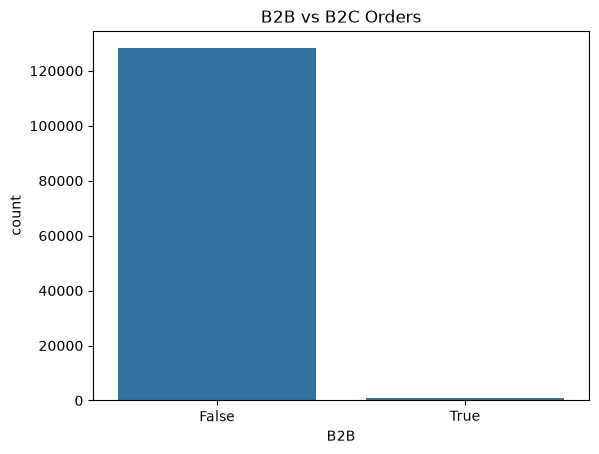

In [26]:
sns.countplot(data=df, x="B2B")
plt.title("B2B vs B2C Orders")
plt.show()

4. Time Series Analysis

In [45]:
# Extract Month
df["Date"].dtype
# df["Month"] = df["Date"].dt.month_name()
df["Date"].head()
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Date"].dtype
df["Month"] = df["Date"].dt.month_name()
df[["Date", "Month"]].head()
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

df["Month"] = pd.Categorical(
    df["Month"],
    categories=month_order,
    ordered=True
)

In [46]:
monthly_sales = df.groupby("Month")["Amount"].sum()
monthly_sales

Month
March      101683.85
April    28836200.27
May      26226476.75
June     23425809.38
Name: Amount, dtype: float64

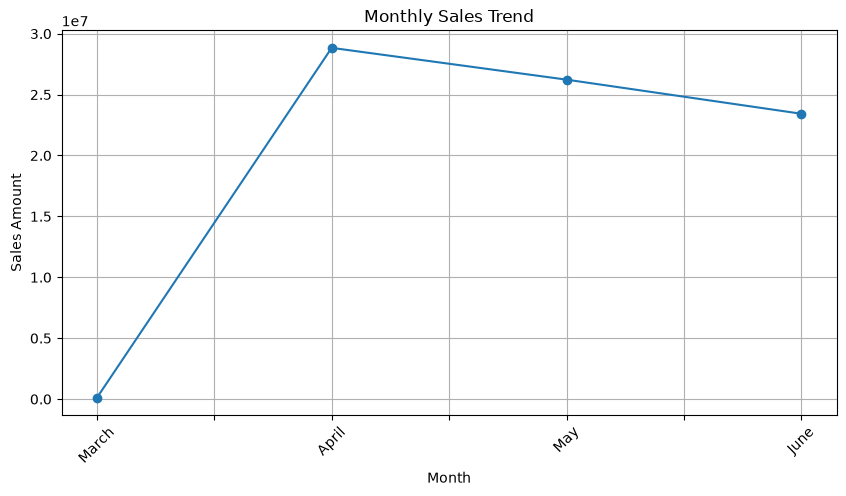

In [47]:
# Monthly Sales
plt.figure(figsize=(10,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

5. Correlation

In [48]:
numeric_df = df.select_dtypes(include=["number"])

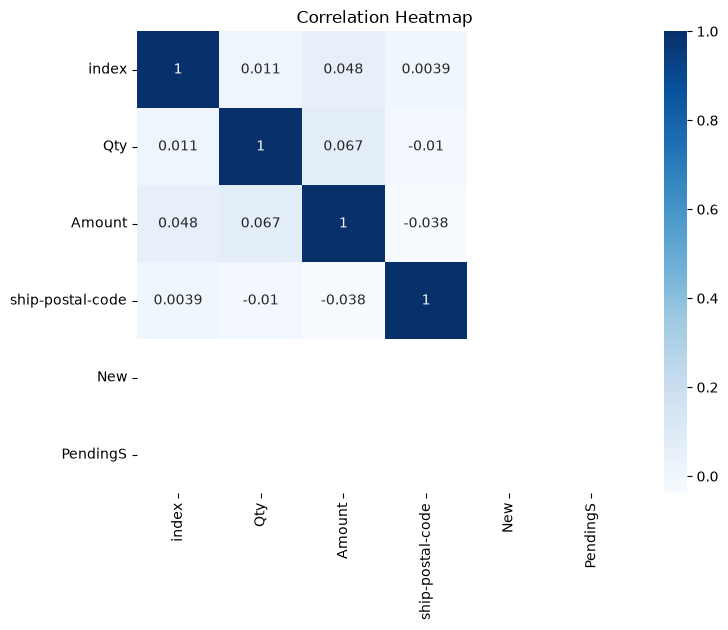

In [33]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

Plot an India Map

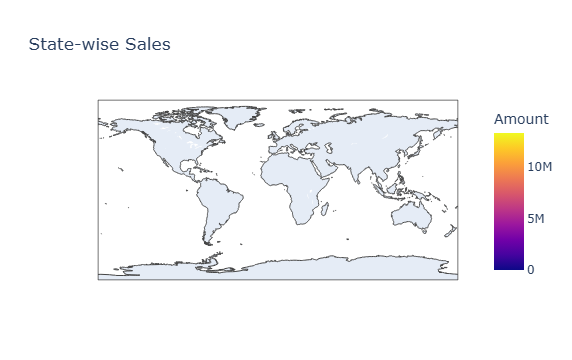

In [50]:
import plotly.express as px

state_sales = (
    df.groupby("ship-state")["Amount"]
      .sum()
      .reset_index()
)

fig = px.choropleth(
    state_sales,
    locations="ship-state",
    locationmode="geojson-id",   # or use state mapping
    color="Amount",
    title="State-wise Sales"
)

fig.show()